In [1]:
import pandas as pd

# Full PaySim dataset ah load pannurom (6.3 million rows)
Fraud_Dataset = pd.read_csv('PS_20174392719_1491204439457_log.csv')
Fraud_Dataset

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [2]:
# Andha full dataset la irundhu, random ah 500 rows sample edukurom
Fraud_sample_500rows = Fraud_Dataset.sample(n=500, random_state=42)# random_state=42 - ithu yadukunaa vara o/p maramaa same mahh varathuku
Fraud_sample_500rows

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4237267,306,CASH_IN,64851.41,C1133286126,51936.00,116787.41,C890377362,7097450.58,7032599.16,0,0
1495524,142,CASH_IN,307084.24,C859180153,2878951.02,3186035.26,C1356915369,993350.55,686266.31,0,0
4608114,329,CASH_IN,9426.71,C173650238,20139.00,29565.71,C109775032,44480.12,35053.41,0,0
506418,20,CASH_OUT,90730.07,C974160097,5242.79,0.00,C447070962,5546453.08,5702938.58,0,0


In [3]:
# Sample ah puthu CSV file ah save pannurom
Fraud_sample_500rows.to_csv('fraud_sample_500.csv', index=False)

In [4]:
print(Fraud_sample_500rows.shape)

(500, 11)


In [5]:
print(Fraud_sample_500rows['isFraud'].value_counts())

isFraud
0    498
1      2
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
fraud_data = pd.read_csv('fraud_sample_500.csv')
fraud_data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [8]:
fraud_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            500 non-null    int64  
 1   type            500 non-null    str    
 2   amount          500 non-null    float64
 3   nameOrig        500 non-null    str    
 4   oldbalanceOrg   500 non-null    float64
 5   newbalanceOrig  500 non-null    float64
 6   nameDest        500 non-null    str    
 7   oldbalanceDest  500 non-null    float64
 8   newbalanceDest  500 non-null    float64
 9   isFraud         500 non-null    int64  
 10  isFlaggedFraud  500 non-null    int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 43.1 KB


In [9]:
fraud_data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,500.000000,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,500.0
mean,240.096000,1.492849e+05,8.848265e+05,9.070751e+05,1.005656e+06,1.081601e+06,0.004000,0.0
std,141.154028,2.782880e+05,3.050350e+06,3.083237e+06,2.686255e+06,2.730225e+06,0.063182,0.0
min,7.000000,6.570000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,155.000000,1.376186e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,232.000000,7.768086e+04,1.449400e+04,0.000000e+00,1.172572e+05,1.598310e+05,0.000000,0.0
75%,330.250000,1.940169e+05,1.049675e+05,1.620512e+05,8.196478e+05,9.517307e+05,0.000000,0.0
max,692.000000,4.126120e+06,2.559175e+07,2.573486e+07,3.685795e+07,3.695526e+07,1.000000,0.0


In [10]:
obj_cols = fraud_data.select_dtypes(include='str').columns
obj_cols

Index(['type', 'nameOrig', 'nameDest'], dtype='str')

In [11]:
int_cols = fraud_data.select_dtypes(include='int').columns
int_cols

Index(['step', 'isFraud', 'isFlaggedFraud'], dtype='str')

In [12]:
fl_cols = fraud_data.select_dtypes(include='float').columns
fl_cols

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest'],
      dtype='str')

Text(0.5, 1.0, 'Transaction Type Countplot')

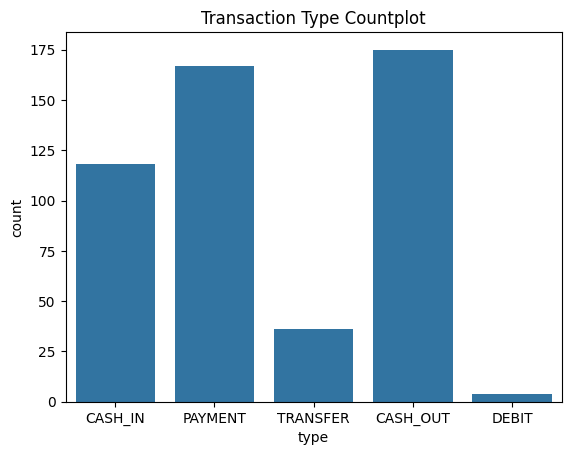

In [13]:
sns.countplot(x='type', data=fraud_data)
plt.title('Transaction Type Countplot')

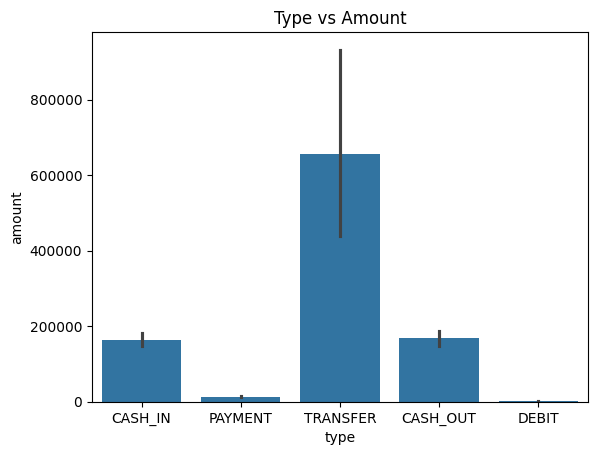

In [14]:
sns.barplot(x='type', y='amount', data=fraud_data)
plt.title('Type vs Amount')
plt.show()

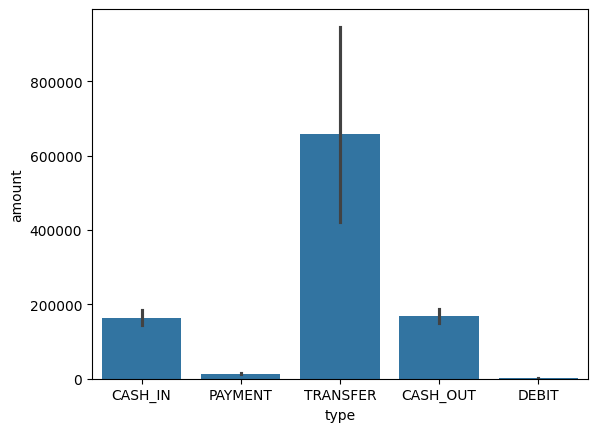

In [15]:
sns.barplot(x='type', y='amount', data=fraud_data)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [16]:
fraud_data['isFraud'].value_counts()

isFraud
0    498
1      2
Name: count, dtype: int64

<Figure size 1500x600 with 0 Axes>

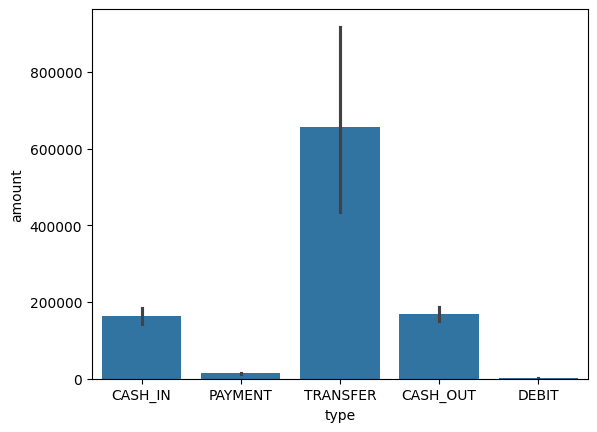

<Figure size 1500x600 with 0 Axes>

In [17]:
sns.barplot(x='type', y='amount', data=fraud_data)
plt.figure(figsize=(15, 6))

<Axes: xlabel='step', ylabel='Count'>

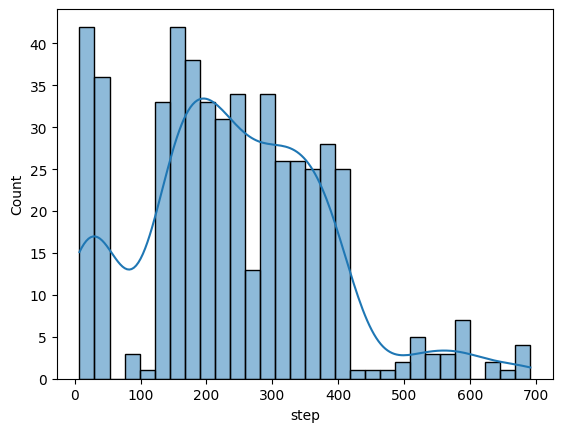

In [18]:
sns.histplot(fraud_data['step'], bins=30, kde=True)

In [19]:
plt.figure(figsize=(12, 6))
corr_data = fraud_data.apply(lambda x: pd.factorize(x)[0])
corr_data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,0,0
2,2,0,2,2,2,2,2,2,2,0,0
3,3,2,3,3,3,3,3,3,3,0,0
4,4,0,4,4,4,4,4,4,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...
495,153,0,495,495,342,212,495,283,304,0,0
496,90,0,496,496,343,213,496,284,305,0,0
497,204,0,497,497,344,214,497,285,306,0,0
498,118,3,498,498,345,3,498,286,307,0,0


<Figure size 1200x600 with 0 Axes>

<Axes: >

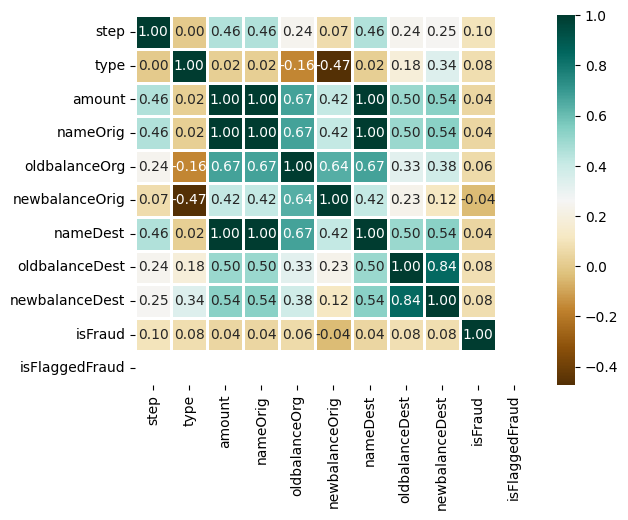

In [20]:
sns.heatmap(corr_data.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)

In [21]:
type_dummies = pd.get_dummies(fraud_data['type'], drop_first=True)

In [22]:
type_dummies

,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,False,False,False,False
1,False,False,True,False
2,False,False,False,False
3,False,False,False,True
4,False,False,False,False
...,...,...,...,...
495,False,False,False,False
496,False,False,False,False
497,False,False,False,False
498,True,False,False,False


In [23]:
fraud_data_new = pd.concat([fraud_data, type_dummies], axis=1)

In [24]:
fraud_data_new

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0,False,False,False,False
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0,False,False,True,False
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0,False,False,False,False
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0,False,False,False,True
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,306,CASH_IN,64851.41,C1133286126,51936.00,116787.41,C890377362,7097450.58,7032599.16,0,0,False,False,False,False
496,142,CASH_IN,307084.24,C859180153,2878951.02,3186035.26,C1356915369,993350.55,686266.31,0,0,False,False,False,False
497,329,CASH_IN,9426.71,C173650238,20139.00,29565.71,C109775032,44480.12,35053.41,0,0,False,False,False,False
498,20,CASH_OUT,90730.07,C974160097,5242.79,0.00,C447070962,5546453.08,5702938.58,0,0,True,False,False,False


In [25]:
X = fraud_data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)

In [26]:
X

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,278,330218.42,20866.00,351084.42,452419.57,122201.15,0,False,False,False,False
1,15,11647.08,30370.00,18722.92,0.00,0.00,0,False,False,True,False
2,10,152264.21,106589.00,258853.21,201303.01,49038.80,0,False,False,False,False
3,403,1551760.63,0.00,0.00,3198359.45,4750120.08,0,False,False,False,True
4,206,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
495,306,64851.41,51936.00,116787.41,7097450.58,7032599.16,0,False,False,False,False
496,142,307084.24,2878951.02,3186035.26,993350.55,686266.31,0,False,False,False,False
497,329,9426.71,20139.00,29565.71,44480.12,35053.41,0,False,False,False,False
498,20,90730.07,5242.79,0.00,5546453.08,5702938.58,0,True,False,False,False


In [27]:
Y = fraud_data_new['isFraud']

In [28]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
495    0
496    0
497    0
498    0
499    0
Name: isFraud, Length: 500, dtype: int64

In [29]:
X.shape, Y.shape

((500, 11), (500,))

In [30]:
import sklearn

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

In [33]:
X_train

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
378,184,402018.27,11328.00,0.00,2871801.44,3273819.71,0,True,False,False,False
313,589,23715.07,18776.87,0.00,0.00,0.00,0,False,False,True,False
443,10,217551.94,2180195.92,2397747.86,727567.81,671031.83,0,False,False,False,False
290,186,378955.73,0.00,0.00,834854.48,1213810.20,0,True,False,False,False
384,140,199757.83,9294672.37,9494430.19,447852.96,248095.14,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
407,15,90548.09,22149.00,0.00,0.00,28502.44,0,True,False,False,False
175,154,39590.21,0.00,0.00,318883.91,358474.12,0,True,False,False,False
284,43,218440.55,52085.00,0.00,0.00,218440.55,0,True,False,False,False
391,330,155905.17,8970.73,0.00,2006093.92,2161999.09,0,True,False,False,False


In [34]:
 X_test 

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
50,544,145319.54,8056.0,0.00,696100.99,841420.53,0,True,False,False,False
367,301,76188.59,10926.0,0.00,286138.53,362327.13,0,True,False,False,False
259,208,125991.42,7310.0,0.00,822675.70,950520.30,0,True,False,False,False
8,230,4865.11,0.0,0.00,0.00,0.00,0,False,False,True,False
174,236,121422.39,0.0,0.00,1626826.73,1748249.12,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
99,206,17485.51,9339.0,0.00,0.00,0.00,0,False,False,True,False
411,35,248823.52,5174.0,0.00,1007073.21,1255896.73,0,True,False,False,False
1,15,11647.08,30370.0,18722.92,0.00,0.00,0,False,False,True,False
102,181,251225.77,41290.0,0.00,5124625.51,5375851.29,0,True,False,False,False


In [35]:
Y_train

378    0
313    0
443    0
290    0
384    0
      ..
407    0
175    0
284    0
391    0
247    0
Name: isFraud, Length: 350, dtype: int64

In [36]:
Y_test

50     0
367    0
259    0
8      0
174    0
      ..
99     0
411    0
1      0
102    0
230    0
Name: isFraud, Length: 150, dtype: int64

In [37]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((350, 11), (350,), (150, 11), (150,))

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [39]:
from sklearn.metrics import roc_auc_score as ras #roc_auc_score evolo nalla predit pannuthu irukura func

In [40]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'GradientBoosting': GradientBoostingClassifier(random_state=7),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)
}

In [41]:
for name, model in models.items():
    model.fit(X_train, Y_train)

In [42]:
train_preds = model.predict_proba(X_train)[:,1]

In [43]:
test_preds = model.predict_proba(X_test)[:,1]
test_preds

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [44]:
print(f"{name}: Train AUC={ras(Y_train, train_preds):.4f}, Test AUC={ras(Y_test, test_preds):.4f}")

RandomForestClassifier: Train AUC=1.0000, Test AUC=0.5000


In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [46]:
y_pred = models['RandomForestClassifier'].predict(X_test)

In [47]:
cm = confusion_matrix(Y_test, y_pred)
cm

array([[149,   0],
       [  1,   0]])

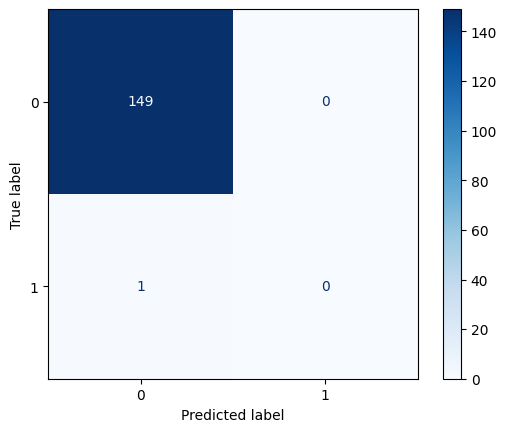

In [48]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()